# SynFS MNIST example
- - horizontal view (3 & 8), w/o artificial bias


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
import numpy as np
from omegaconf import OmegaConf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import torch
import torch.nn as nn 
from torch.utils.data import DataLoader

#mnist
from torchvision import datasets, transforms

from src.trainer.trainer import SynFSTrainer
from src.models.synfs_model import SynFSModel 
from src.data.dataset import SimpleDataset

In [4]:
views_dims = [392,392]

In [5]:
cfg = OmegaConf.create({
    "model": {
        "views_dims": views_dims,
        "hidden_dims": [400, 200, 300],
        "output_dim":2,
        "batch_norm":True,
        "dropout":True,
        "activation": "relu",
        "learning_rate": 1e-3,
        "s_learning_rate": 1e-2,
        "weight_decay": 1e-4,
        "s_lam": 0.4,
        "ns_lam": 4,
        "ns_alpha": 0.09,
    },
    "nr_epochs": 100,
    "seed": 0,
    "device": "cpu"
})

In [6]:
top_k =28

In [7]:
from os import mkdir
from os.path import isdir


root_path = './mnist'

if not isdir(root_path):
    mkdir(root_path)

In [8]:
train_set_raw = datasets.MNIST(
    root = root_path,
    train = True,
    download = True,
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
)
test_set_raw = datasets.MNIST(
    root = root_path,
    train = False,
    download = True,
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
)


In [9]:
def filter_data(train_set_raw, test_set_raw, label1, label2):
    """
    label1 :3
    lebel2 : 8
    """
    train_set = list(filter(lambda i: i[1] == int(label1) or i[1]== int(label2) , train_set_raw))  # train_set_raw (image, number_label)
    test_set = list(filter(lambda i: i[1] == int(label1) or i[1]==int(label2) , test_set_raw))
    return train_set, test_set

In [10]:
train_set, test_set = filter_data(train_set_raw, 
                                  test_set_raw,
                                  3,8)

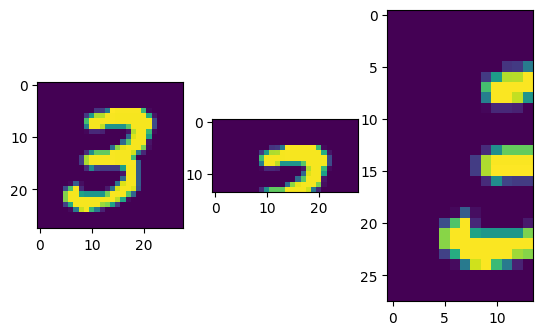

In [11]:
fig, axes = plt.subplots(1,3)
axes[0].imshow(train_set[0][0].reshape(28,28))
axes[1].imshow(train_set[0][0][:,:14,:].reshape(14,28))  # horizontal view 
axes[2].imshow(train_set[0][0][:,:,:14].reshape(28,14))  


In [12]:
def mnist_2_views_maker(data_set, label1, label2):
    """
    make mnist to two view dataset (vertically slice the image)
    return type ([view1,view2],label), view1 = (n, features)
    label1 :3 
    label2 :8
    """
    view1 = []
    view2 = []
    labels = []
    for i in range(len(data_set)): 
        if data_set[i][1]==int(label1):
            view1.append(data_set[i][0][:,:14,:].flatten())
            view2.append(data_set[i][0][:,14:,:].flatten())
            labels.append(0)

        elif data_set[i][1]==int(label2):
            view1.append(data_set[i][0][:,:14,:].flatten())
            view2.append(data_set[i][0][:,14:,:].flatten())
            labels.append(1)
        
        else :
            pass
    data = ([np.stack(view1, axis=0), np.stack(view2, axis=0)],np.array(labels))
    return data 


In [13]:
train_data = mnist_2_views_maker(train_set, 3, 8)
test_data = mnist_2_views_maker(test_set, 3, 8)

In [14]:
np.unique(train_data[1], return_counts=True)

(array([0, 1]), array([6131, 5851]))

1379


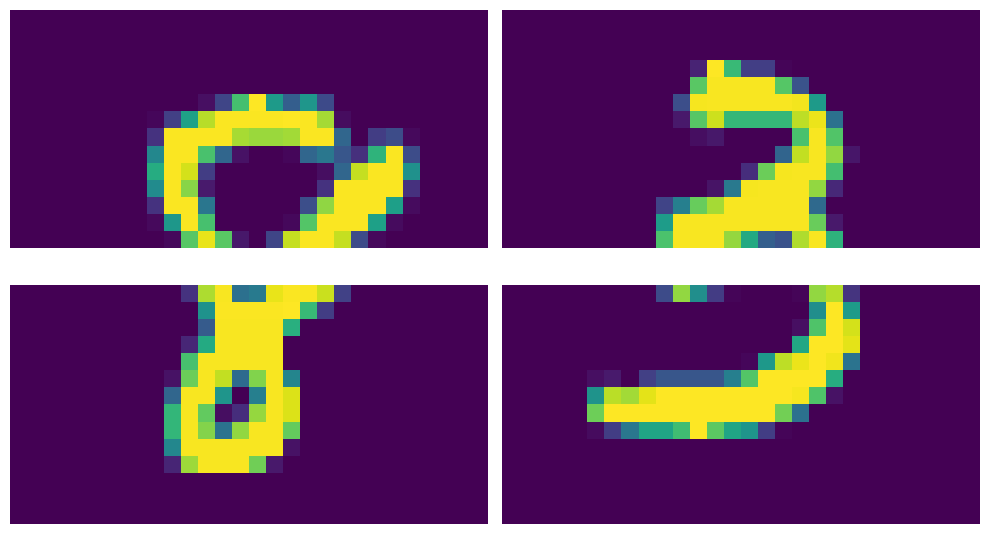

In [15]:
X_set = test_data[0]
number = np.random.randint(len(X_set[0]))
print(number)
for n in range(number, number+1):
    fig, axes = plt.subplots(2,2, figsize=(10,6))
    for idx, i in enumerate(range(n,n+2)):
        axes[0,idx].imshow(X_set[0][i].reshape(14,28))
        axes[1,idx].imshow(X_set[1][i].reshape(14,28))
        axes[0,idx].axis('off')
        axes[1,idx].axis('off')

plt.tight_layout()
plt.show()

In [16]:
train_set, test_set = filter_data(train_set_raw, test_set_raw, 3,8)
train_data = mnist_2_views_maker(train_set, 3, 8)
test_data = mnist_2_views_maker(test_set, 3, 8)


In [17]:
# train, val, test split
tr_X_set, tr_y = train_data[0], train_data[1]
te_X_set, te_y = test_data[0], test_data[1]
n = len(tr_X_set[1])
train_indices, val_indices = train_test_split(np.arange(n), test_size=0.2, random_state=0)
va_X_set, va_y = [X[val_indices] for X in tr_X_set], tr_y[val_indices]
tr_X_set, tr_y = [X[train_indices] for X in tr_X_set], tr_y[train_indices]

In [18]:
# scaling
scaled_tr_X_set, scalers = [], []
for i, view_data in enumerate(tr_X_set):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(view_data)
    scaled_tr_X_set.append(scaled_data)
    scalers.append(scaler)
scaled_va_X_set = [scalers[i].transform(va_X_set[i]) for i in range(len(va_X_set))]
scaled_te_X_set = [scalers[i].transform(te_X_set[i]) for i in range(len(te_X_set))]

tr_X_set, va_X_set, te_X_set = scaled_tr_X_set.copy(), scaled_va_X_set.copy(), scaled_te_X_set.copy()
        

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_data = SimpleDataset(tr_X_set, tr_y, device=device)
val_data   = SimpleDataset(va_X_set, va_y, device)

train_loader = DataLoader(train_data, batch_size=250, drop_last=True, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=250, drop_last=False, shuffle=False)

print("Train size:", len(train_data))
print("Val size:", len(val_data))

Train size: 9585
Val size: 2397


In [21]:
from src.utils.feature_importance import get_important_features

In [ ]:
model = SynFSModel(cfg.model).to(cfg.device)
trainer = SynFSTrainer(cfg,model)


history = {"train_loss": [], "val_auroc": []}
trainer.set_X_mean_set(train_loader)

for epoch in range(cfg.nr_epochs):
    train_metrics = trainer.train_epoch(train_loader)
    val_metrics   = trainer.validate_epoch(val_loader)

    history["train_loss"].append(train_metrics["loss"])
    history["val_auroc"].append(val_metrics["auroc"])


    if epoch % 30 == 0:
        print("======Epoch", epoch, "Train Loss:", train_metrics['loss'], "Val AUROC:", val_metrics['auroc'], "======")
        
        get_important_features(
            model,
            which="synergistic",
            threshold=0.7,
            verbose=True
        )
        get_important_features(
            model,
            which="non_synergistic",
            threshold=0.7,
            verbose=True
        )
        print('\n')

======Epoch 0 Train Loss: 2.463724417121787 Val AUROC: 0.9880339051241606 ======
[synergistic] threshold=0.7
  total features     : 784
  selected features  : 2
  indices: [348 565]
[non_synergistic] threshold=0.7
  total features     : 784
  selected features  : 0
  indices: []


======Epoch 30 Train Loss: -0.3519699244122756 Val AUROC: 0.9980288215492304 ======
[synergistic] threshold=0.7
  total features     : 784
  selected features  : 24
  indices: [179 218 239 242 246 299 300 302 327 328 329 565 593 650 651 652 653 654
 655 665 682 683 708 712]
[non_synergistic] threshold=0.7
  total features     : 784
  selected features  : 16
  indices: [151 265 276 291 293 316 317 319 374 457 459 484 514 516 517 540]




## Evaluation

### Feature Discovery

In [ ]:
# gate plot
def get_gates(model, interaction:'str', threshold=None):
    # return list of view gates, concat of view gate 
    assert interaction in {"synergistic", "non_synergistic"}
    if interaction == 'synergistic':
        model_gate = model.get_gates(model.s_model)
    elif interaction == 'non_synergistic':
        model_gate = model.get_gates(model.ns_model)


    if threshold is None:
        gates = [gate.cpu().numpy() for gate in model_gate]
    else:
        gates = [np.where(gate.cpu().numpy()>threshold, 1, 0) for gate in model_gate]
    a, b = gates
    gate = np.concatenate([a,b])
    return gates, gate 



def highest_n_gates(gates, n=6): 
    #return gate with n hightest gate 
    ai_gates_ = []
    for gate in gates:
        indices = np.argsort(gate)[-n:]
        gate = np.zeros_like(gate)
        gate[indices] = 1
        ai_gates_.append(gate)
        
    return ai_gates_

In [ ]:
s_gates, s_gate = get_gates(model, 'synergistic')
n_gates, n_gate = get_gates(model, 'non_synergistic')

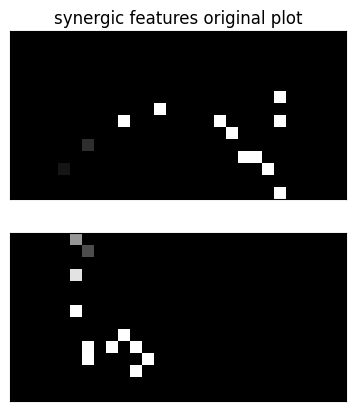

In [ ]:
fig, axes = plt.subplots(2,1)
axes[0].set_title(f"synergic features original plot")
axes[0].xaxis.set_visible(False)
axes[0].yaxis.set_visible(False)
axes[1].xaxis.set_visible(False)
axes[1].yaxis.set_visible(False)
axes[0].imshow(s_gates[0].reshape(14,28), cmap='gray');
axes[1].imshow(s_gates[1].reshape(14,28), cmap='gray');


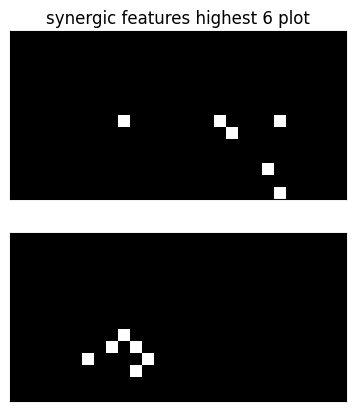

In [ ]:
n = 6
s_gates_ = highest_n_gates(s_gates, n)
fig, axes = plt.subplots(2,1)
axes[0].set_title(f"synergic features highest {n} plot")
axes[0].xaxis.set_visible(False)
axes[0].yaxis.set_visible(False)
axes[1].xaxis.set_visible(False)
axes[1].yaxis.set_visible(False)
axes[0].imshow(s_gates_[0].reshape(14,28), cmap='gray');
axes[1].imshow(s_gates_[1].reshape(14,28), cmap='gray');

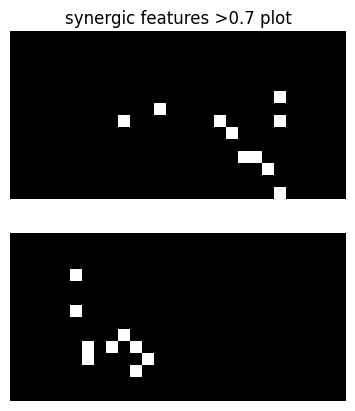

In [ ]:
fig, axes = plt.subplots(2,1)
axes[0].set_title(f"synergic features >0.7 plot")
axes[0].axis('off')      
axes[1].axis('off')  
axes[0].imshow(np.where(s_gates[0]>0.7, 1, 0).reshape(14,28), cmap='gray');
axes[1].imshow(np.where(s_gates[1]>0.7, 1, 0).reshape(14,28), cmap='gray');

In [ ]:
np.where(s_gates[0]>0.7)[0]

array([162, 180, 205, 213, 218, 242, 299, 300, 329, 386])

In [ ]:
s_gates

[array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

556


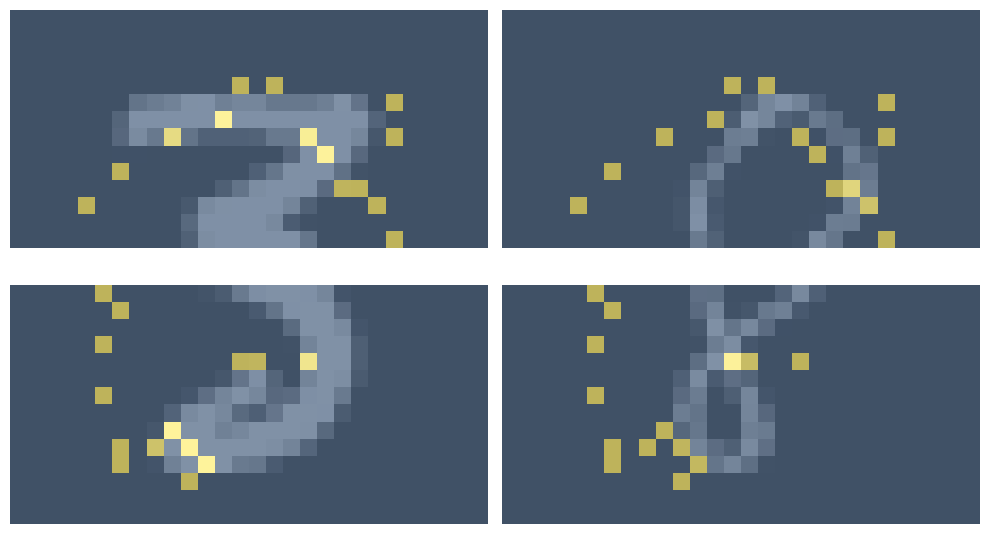

In [ ]:
#number = 5052
number = 556 #1626
#number = np.random.randint(len(X_set[0]))
print(number)

fig, axes = plt.subplots(2,2, figsize=(10,6))
s_gates_ = highest_n_gates(s_gates, int(top_k/2))
for idx, i in enumerate(range(number, number+2)):
    axes[0,idx].imshow(X_set[0][i].reshape(14,28), cmap='gray', alpha=0.5)
    #axes[0,idx].imshow(np.where(s_gates[0]>0.7, 1, 0).reshape(14,28), cmap='cividis', alpha=0.5)
    axes[0,idx].imshow(s_gates_[0].reshape(14,28), cmap='cividis', alpha=0.5)
    axes[1,idx].imshow(X_set[1][i].reshape(14,28), cmap='gray', alpha=0.5)
    #axes[1,idx].imshow(np.where(s_gates[1]>0.7, 1, 0).reshape(14,28), cmap='cividis', alpha=0.5)
    axes[1,idx].imshow(s_gates_[1].reshape(14,28), cmap='cividis', alpha=0.5)
    axes[0,idx].axis('off')      
    axes[1,idx].axis('off')     
plt.tight_layout()
plt.show()

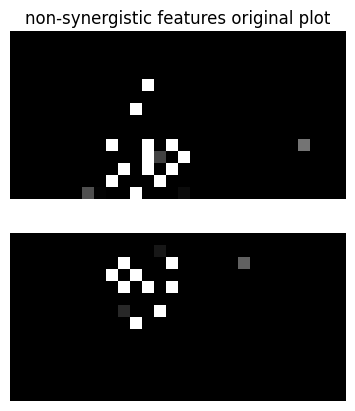

In [ ]:
fig, axes = plt.subplots(2,1)
axes[0].set_title(f"non-synergistic features original plot")
axes[0].imshow(n_gates[0].reshape(14,28), cmap='gray');
axes[1].imshow(n_gates[1].reshape(14,28), cmap='gray');
axes[0].axis('off')
axes[1].axis('off');

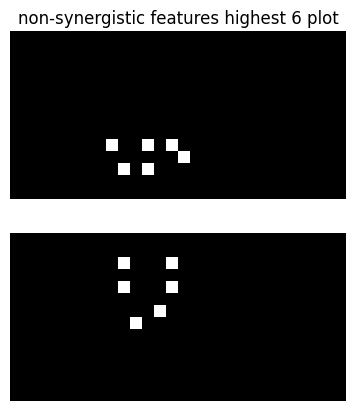

In [ ]:
n = 6
n_gates_ = highest_n_gates(n_gates, n)
fig, axes = plt.subplots(2,1)
axes[0].set_title(f"non-synergistic features highest {n} plot")
axes[0].imshow(n_gates_[0].reshape(14,28), cmap='gray');
axes[1].imshow(n_gates_[1].reshape(14,28), cmap='gray');
axes[0].axis('off')
axes[1].axis('off');

556


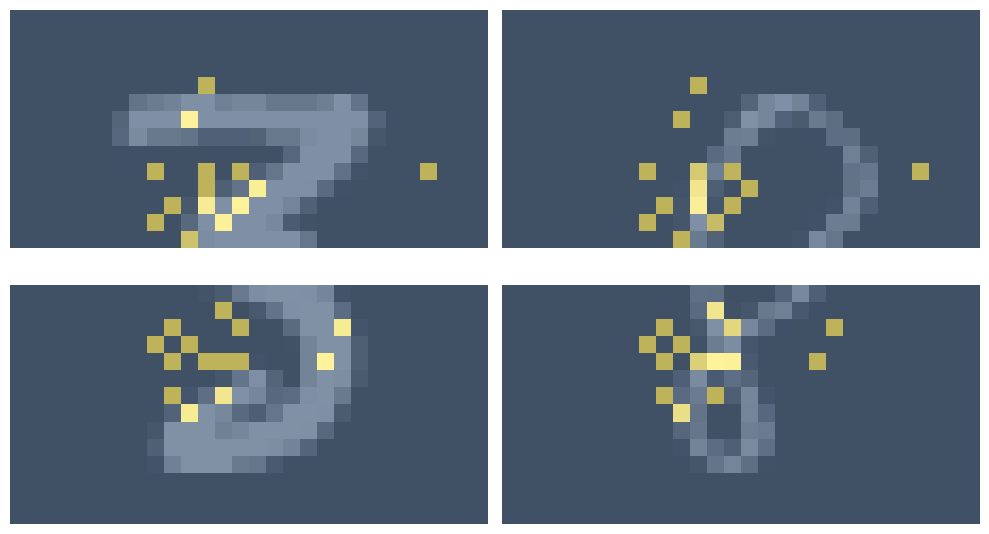

In [ ]:
number = 556
#number = 5052
#number = np.random.randint(len(X_set[0]))
print(number)
n_gates_ = highest_n_gates(n_gates, int(top_k/2))
for n in range(number, number+1):
    fig, axes = plt.subplots(2,2, figsize=(10,6))
    for idx, i in enumerate(range(n, n+2)):
        axes[0,idx].imshow(X_set[0][i].reshape(14,28), cmap='gray', alpha=0.5)
        axes[0,idx].imshow(n_gates_[0].reshape(14,28), cmap='cividis', alpha=0.5)
        axes[1,idx].imshow(X_set[1][i].reshape(14,28), cmap='gray', alpha=0.5)
        axes[1,idx].imshow(n_gates_[1].reshape(14,28), cmap='cividis', alpha=0.5)
        axes[0,idx].axis('off')      
        axes[1,idx].axis('off')    

plt.tight_layout()
plt.show()

### Predictive Performance

In [ ]:
from src.metric.metric import standard_metrics

In [ ]:
data = SimpleDataset(te_X_set, te_y, device=device)
testloader = DataLoader(data, batch_size=len(te_y))
           
res = []
for x, y in testloader:
    logits = trainer.predict(x)
    res.append(logits.detach().cpu().numpy())
logits = np.concatenate(res)

auroc, auprc, accuracy, f1 = standard_metrics(tr_y, te_y, logits, verbose=True)

auroc | 1.000, auprc | 1.000, accuracy | 0.993, f1 | 0.993
